# Import Libraries


In [6]:
#  Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid', palette='muted', font_scale=1.1)

#  Load Dataset and Inspect

In [11]:
# Load dataset
df = pd.read_csv('/kaggle/input/datasets/saurabhshahane/road-traffic-accidents/RTA Dataset.csv') 

# Display top 5 rows
df.head()

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,...,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,...,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury


In [ ]:
# Observation:
#The dataset contains features related to driver, vehicle, road, and environmental conditions.
# Target variable is `Accident_severity`. Some columns may contain missing values or inconsistencies.

#  Statistical Analysis

In [12]:
# Check data info and types
df.info()

# Check numeric statistics
df.describe()

# Check missing values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Time                         12316 non-null  object
 1   Day_of_week                  12316 non-null  object
 2   Age_band_of_driver           12316 non-null  object
 3   Sex_of_driver                12316 non-null  object
 4   Educational_level            11575 non-null  object
 5   Vehicle_driver_relation      11737 non-null  object
 6   Driving_experience           11487 non-null  object
 7   Type_of_vehicle              11366 non-null  object
 8   Owner_of_vehicle             11834 non-null  object
 9   Service_year_of_vehicle      8388 non-null   object
 10  Defect_of_vehicle            7889 non-null   object
 11  Area_accident_occured        12077 non-null  object
 12  Lanes_or_Medians             11931 non-null  object
 13  Road_allignment              12

Time                              0
Day_of_week                       0
Age_band_of_driver                0
Sex_of_driver                     0
Educational_level               741
Vehicle_driver_relation         579
Driving_experience              829
Type_of_vehicle                 950
Owner_of_vehicle                482
Service_year_of_vehicle        3928
Defect_of_vehicle              4427
Area_accident_occured           239
Lanes_or_Medians                385
Road_allignment                 142
Types_of_Junction               887
Road_surface_type               172
Road_surface_conditions           0
Light_conditions                  0
Weather_conditions                0
Type_of_collision               155
Number_of_vehicles_involved       0
Number_of_casualties              0
Vehicle_movement                308
Casualty_class                    0
Sex_of_casualty                   0
Age_band_of_casualty              0
Casualty_severity                 0
Work_of_casuality           

In [ ]:
# Observations:
#- Identify numeric and categorical columns.
#- Many categorical features have missing values (e.g., Age_band_of_driver, Educational_level).
#- Some numeric columns may have missing values (e.g., Number_of_casualties).
#- Cleaning is required for preprocessing.

# Visual Analysis

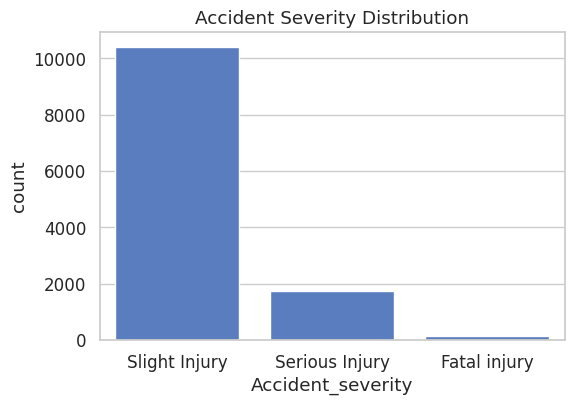

In [15]:
#Target Variable Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Accident_severity', data=df)
plt.title('Accident Severity Distribution')
plt.show()

In [ ]:
# Observation:
# Most accidents are of Slight Injury type; Serious Injury accidents are less frequent. This imbalance may affect model performance.

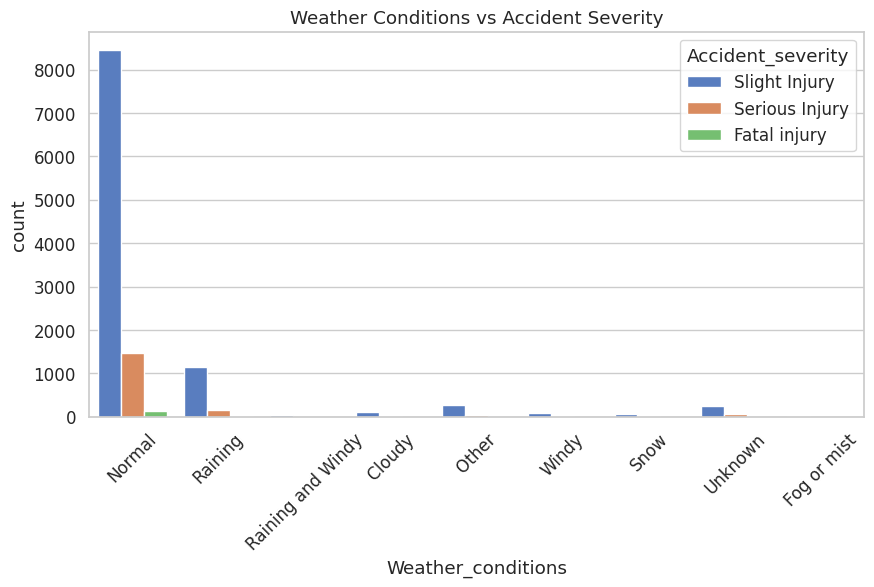

In [16]:
# Weather Conditions vs Accident Severity
plt.figure(figsize=(10,5))
sns.countplot(x='Weather_conditions', hue='Accident_severity', data=df)
plt.title('Weather Conditions vs Accident Severity')
plt.xticks(rotation=45)
plt.show()

In [30]:
# Observation:
# Certain weather conditions like Raining or Wet/Damp roads have higher proportion of serious injuries.

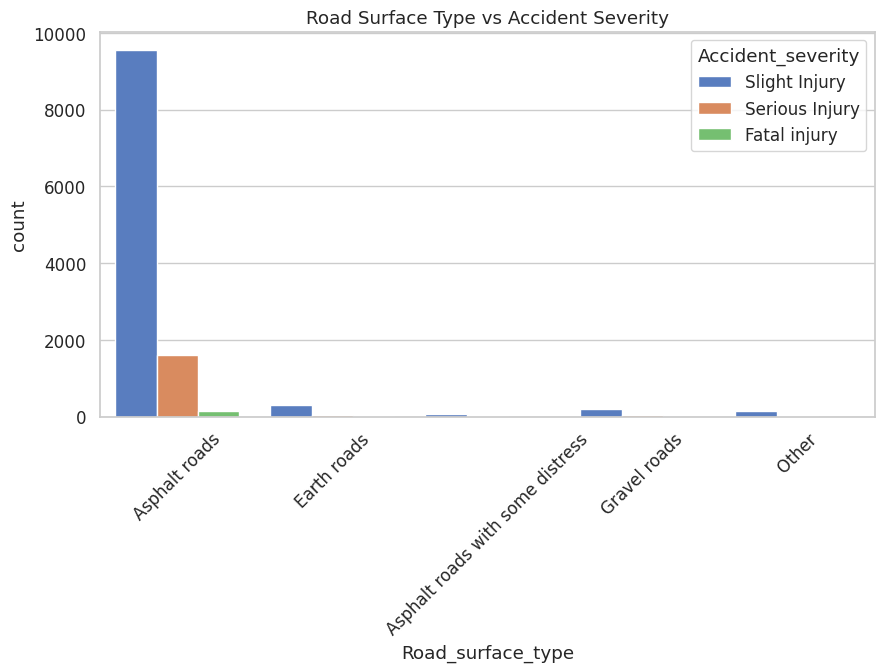

In [17]:
# Road Type vs Accident Severity
plt.figure(figsize=(10,5))
sns.countplot(x='Road_surface_type', hue='Accident_severity', data=df)
plt.title('Road Surface Type vs Accident Severity')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Observation:
# Accidents on Earth or Gravel roads tend to have more severe outcomes.

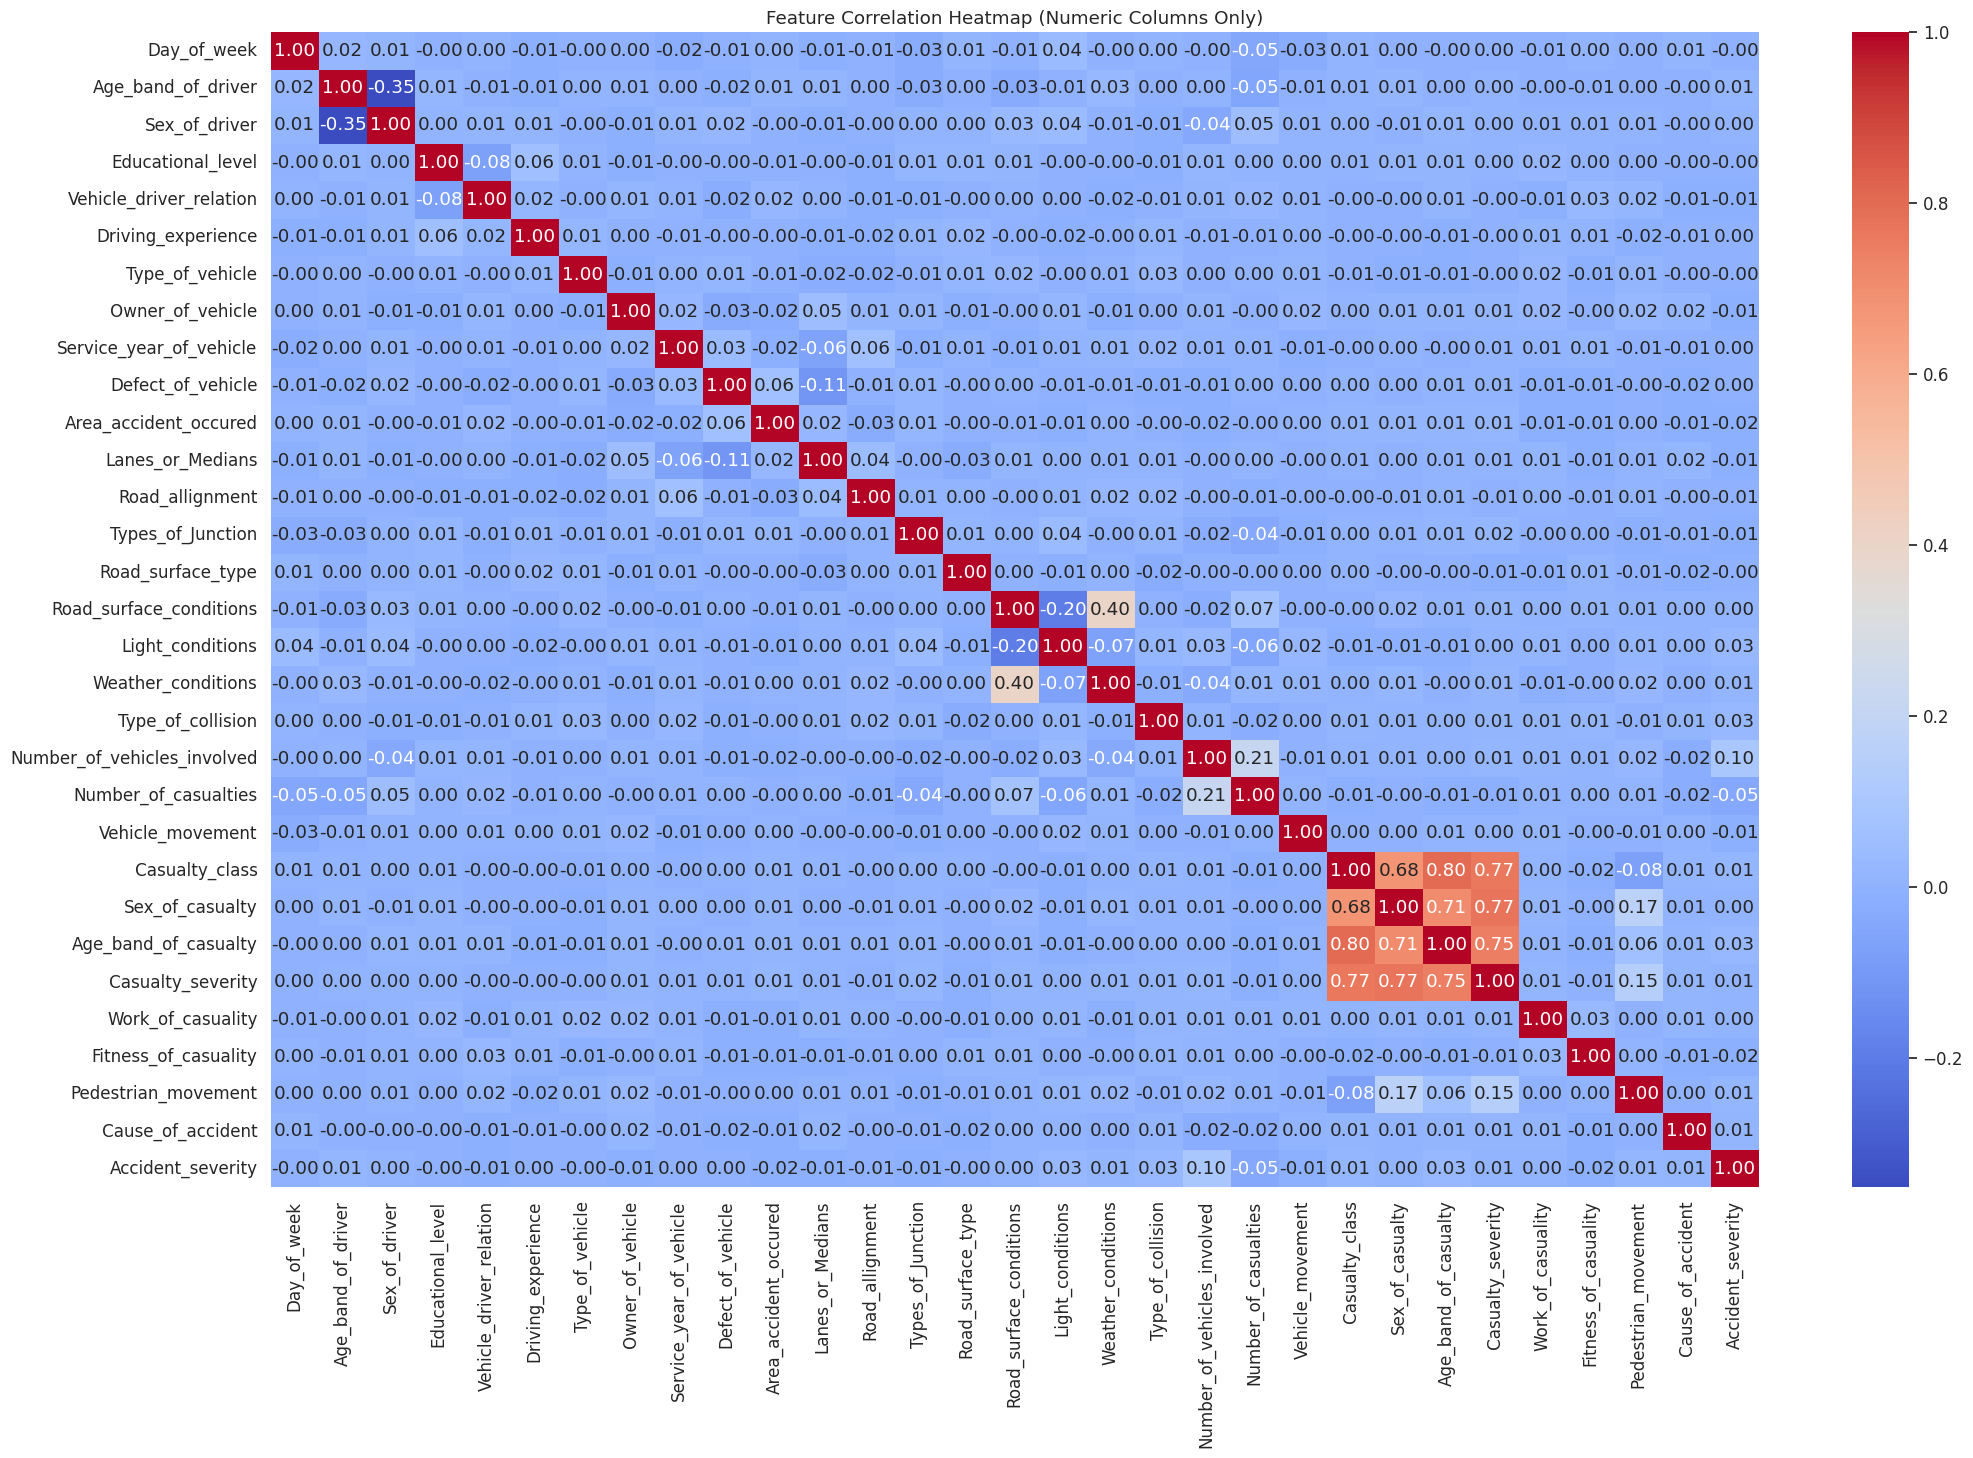

In [29]:
# Numeric Feature Correlation
# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(24,15))
sns.heatmap(numeric_df.corr(), cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Feature Correlation Heatmap (Numeric Columns Only)")
plt.show()

# Preprocessing

In [21]:
# Handle Missing Values
# Fill categorical features with mode
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])
    print(f"{col} missing values filled with mode.")

# Fill numeric features with median
for col in df.select_dtypes(include='number').columns:
    df[col] = df[col].fillna(df[col].median())
    print(f"{col} missing values filled with median.")

Time missing values filled with mode.
Day_of_week missing values filled with mode.
Age_band_of_driver missing values filled with mode.
Sex_of_driver missing values filled with mode.
Educational_level missing values filled with mode.
Vehicle_driver_relation missing values filled with mode.
Driving_experience missing values filled with mode.
Type_of_vehicle missing values filled with mode.
Owner_of_vehicle missing values filled with mode.
Service_year_of_vehicle missing values filled with mode.
Defect_of_vehicle missing values filled with mode.
Area_accident_occured missing values filled with mode.
Lanes_or_Medians missing values filled with mode.
Road_allignment missing values filled with mode.
Types_of_Junction missing values filled with mode.
Road_surface_type missing values filled with mode.
Road_surface_conditions missing values filled with mode.
Light_conditions missing values filled with mode.
Weather_conditions missing values filled with mode.
Type_of_collision missing values fil

In [ ]:
# Reason:
# Categorical features cannot have missing values for ML. Numeric missing values are filled with median to reduce the effect of outliers.

In [22]:
# Encode Categorical Features
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])
    print(f"{col} encoded.")

Time encoded.
Day_of_week encoded.
Age_band_of_driver encoded.
Sex_of_driver encoded.
Educational_level encoded.
Vehicle_driver_relation encoded.
Driving_experience encoded.
Type_of_vehicle encoded.
Owner_of_vehicle encoded.
Service_year_of_vehicle encoded.
Defect_of_vehicle encoded.
Area_accident_occured encoded.
Lanes_or_Medians encoded.
Road_allignment encoded.
Types_of_Junction encoded.
Road_surface_type encoded.
Road_surface_conditions encoded.
Light_conditions encoded.
Weather_conditions encoded.
Type_of_collision encoded.
Vehicle_movement encoded.
Casualty_class encoded.
Sex_of_casualty encoded.
Age_band_of_casualty encoded.
Casualty_severity encoded.
Work_of_casuality encoded.
Fitness_of_casuality encoded.
Pedestrian_movement encoded.
Cause_of_accident encoded.
Accident_severity encoded.


In [ ]:
# Reason:
# Machine learning models require numeric inputs. Label encoding converts categories to numeric labels while preserving information.

In [23]:
# Drop Irrelevant Columns
# Drop identifier or redundant columns if any
if 'Time' in df.columns:
    df = df.drop('Time', axis=1)
    print("Time column dropped as not needed for modeling.")

Time column dropped as not needed for modeling.


In [ ]:
# Reason:
# Time may not provide predictive power for accident severity and can be ignored in this phase.

In [24]:
# Save Preprocessed Dataset
df.to_csv('RTA_Cleaned.csv', index=False)
print("Preprocessed dataset saved as RTA_Cleaned.csv.")

Preprocessed dataset saved as RTA_Cleaned.csv.
